# Velocity Slicing Nebulae

Taking a single image of colliding wind nebulae is incredibly useful and can sensitively constrain many orbital/wind parameters of the system from the get-go. To constrain the remaining orbital or wind parameters, however, you typically need many epochs of imaging. Even with this, it can still be difficult to unambiguously determine some parameters which can be covariant and/or degenerate.

Another useful tool, should you have access, is a data cube; not only do you have two spatial dimensions for your dust emission, but you have a third dimension corresponding to the spectrum of each pixel. If you can isolate a particular emission line, you then essentially have a dimension that encodes the radial velocity of the bright dust/gas.

In this tutorial we describe how you can use `xenomorph` to velocity-slice produced nebulae in order to compare with integral field data.

In [1]:
import sys; sys.path.append('../..')    # ignore this! just needed since this file is away from the xenomorph root dir

# start off by importing the relevant modules
import xenomorph.geometry as gm 
import xenomorph.systems as wrb

# and some other important packages
import numpy as np
import matplotlib.pyplot as plt

Let's choose to generate 10 shells of the WR140 dust nebula as a way to visualise `xenomorph`'s functionality. 

In [2]:
system = wrb.WR140.copy()
shells = 10
bins = 12   # let's automatically slice the range of particle radial velocities into 12 equally sized bins
velocity_structure, particles = gm.radial_velocity_points(system, shells=shells, bins=bins, n_t=1000, n_points=400)

The above code has obtained the radial velocities of all of the particles in the point cloud, and saved it into the `velocity_structure` variable. This is a specially formated dictionary, and the documentation entry for it is
```
velocity_structure : dict
        A dictionary with keywords 'bin_width' (the width of each velocity bin), 'bin_centres' (a 1xbins) array of velocities that are the centre of each bin,
        and an int keyword for each bin centre where each is a dict of {'particles':(3x?), 'weights':(1x?)} of the particles that correspond to the bin with that central velocity.
```
Now let's continue with the tutorial and map those particles into an image for each velocity bin.

In [3]:
# let's do a 600x600 image for each velocity bin
velocity_cube, xedges, yedges = gm.radial_velocity_cube(system, velocity_structure, particles, resolution=600)

We've now calculated the 'dust emission' in each velocity bin, so now we can plot it. Given we chose 12 shells, I am going to plot a 4x3 grid of these slices:

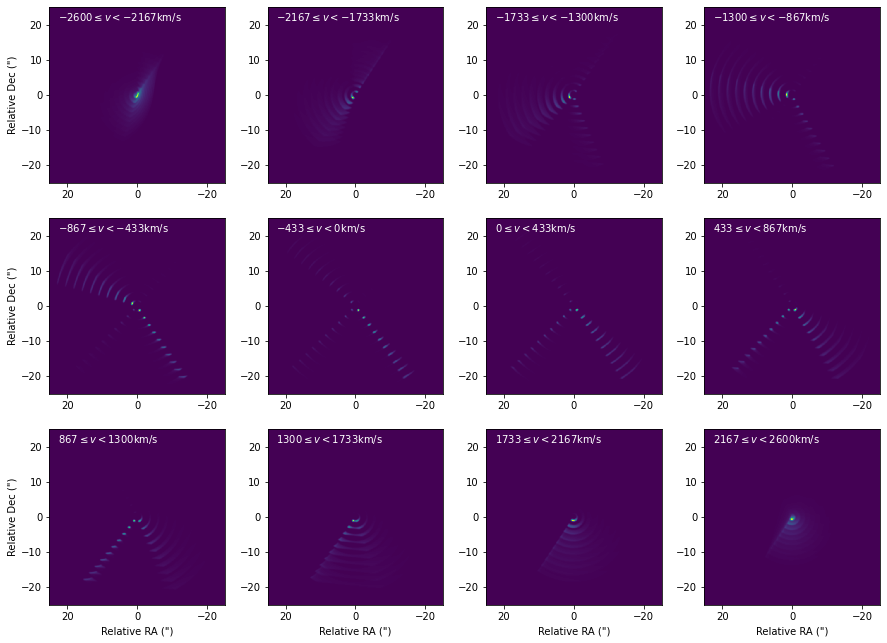

In [4]:
fig, axes = plt.subplots(ncols=4, nrows=3, figsize=(15, 11))

for i in range(3):  # for each row...
    for j in range(4):  # for each column...
        bin_no = 4*i+j   # keeps count of our increasing slice number accounting for the grid position
        axes[i, j].pcolormesh(-xedges, yedges, velocity_cube[:, :, bin_no])         # plot the velocity slice
        
        # now let's add a bit of text to show the velocity range we're looking at in each bin.
        # start by getting the upper and lower velocity bound:
        lower = velocity_structure['bin_centres'][bin_no] - velocity_structure['bin_widths'][bin_no] / 2
        upper = velocity_structure['bin_centres'][bin_no] + velocity_structure['bin_widths'][bin_no] / 2
        text = fr"${lower:.0f}\leq v < {upper:.0f}$km/s"    # format the text correctly
        # now to add the text in the top left corner
        axes[i, j].text(-0.9 * np.min(xedges), 0.85 * np.max(yedges), text, c='w')
        
        axes[i, j].set(aspect='equal')
        axes[i, j].xaxis.set_inverted(True)
        if i == 2:
            axes[i, j].set_xlabel('Relative RA (")')
        if j == 0:
            axes[i, j].set_ylabel('Relative Dec (")')

And we're done!
The above gives equally sized velocity bins, from the fastest receding particle all the way to the fastest approaching particle. That may not always be what we want, though. Perhaps we only care about a narrow collection of radial velocities for whatever reason. Thankfully, we can supply our own bins if we want to do this!

As before, let's go with 10 shells of WR140. This time, instead of supplying our `bins` keyword argument with an integer, we'll supply it with a dictionary. The documentation for doing this requires that it is:
```
A dictionary with two keywords: 'bin_widths' and 'bin_centres', where the data on each keyword is a (1 x bins) array corresponding to 
            each bin width and each bin centre. In this way, you can have irregularly sized/spaced bins.
```
Let's try it out with some custom bins.

In [ ]:
# let's go with 3 bins of varying size and position. All values are in units of km/s
custom_bins = {'bin_widths':[1000, 200, 500], 'bin_centres':[-2000, 0, 1000]}
velocity_structure, particles = gm.radial_velocity_points(system, shells=shells, bins=custom_bins, n_t=1000, n_points=400)

# let's do a 600x600 image for each velocity bin as before
velocity_cube, xedges, yedges = gm.radial_velocity_cube(system, velocity_structure, particles, resolution=600)

Now let's plot this in a simple 1x3 grid:

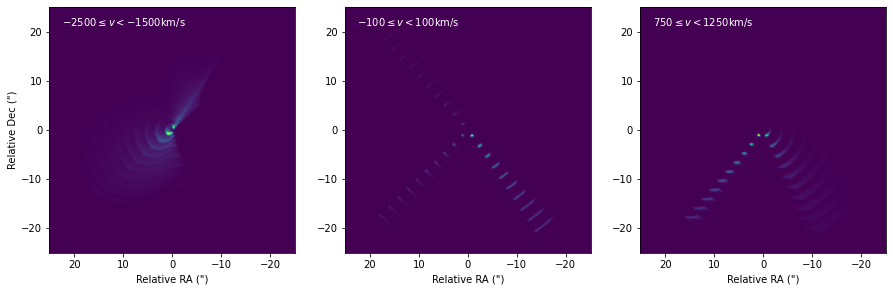

In [7]:
fig, axes = plt.subplots(ncols=3, figsize=(15, 6))

for bin_no in range(3):  # for each column...
    axes[bin_no].pcolormesh(-xedges, yedges, velocity_cube[:, :, bin_no])         # plot the velocity slice
    
    # now let's add a bit of text to show the velocity range we're looking at in each bin.
    # start by getting the upper and lower velocity bound:
    lower = velocity_structure['bin_centres'][bin_no] - velocity_structure['bin_widths'][bin_no] / 2
    upper = velocity_structure['bin_centres'][bin_no] + velocity_structure['bin_widths'][bin_no] / 2
    text = fr"${lower:.0f}\leq v < {upper:.0f}$km/s"    # format the text correctly
    # now to add the text in the top left corner
    axes[bin_no].text(-0.9 * np.min(xedges), 0.85 * np.max(yedges), text, c='w')
    
    axes[bin_no].set(aspect='equal', xlabel='Relative RA (")')
    axes[bin_no].xaxis.set_inverted(True)
    if bin_no == 0:
        axes[bin_no].set_ylabel('Relative Dec (")')

And there you have it! With `xenomorph` you can slice our fancy colliding wind nebulae into automatically sized velocity bins, or bins (of any size) that you've defined and care about in particular. 